In [2]:
import os
import re
import glob
import numpy as np
import pandas as pd
import mdtraj as md
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path

try:
    from docking_tools import trajectory_analysis, plotting
    HAS_DOCKING_TOOLS = True
except ImportError:
    print("WARNING: docking_tools not found - interaction fingerprints disabled")
    HAS_DOCKING_TOOLS = False

In [3]:
# ================================================================
# Parameteres and indices for atoms
# ================================================================
CONTACT_ANG = 6.0
CONTACT_NM  = CONTACT_ANG / 10.0
N_BINS      = 20

LIGAND_RESID_PAPER = 21

LIG_HEAVY_PAPER = [294, 295, 296, 297, 298, 299, 300, 301, 302, 303,
                   304, 305, 306, 307, 308, 309, 310, 311, 312, 313,
                   316, 317]
LIG_H_PAPER = [314, 315, 318, 319, 320, 321, 322, 323, 324, 325,
               326, 327, 328, 329, 330, 331, 332, 333, 334, 335,
               336, 337]
assert len(LIG_HEAVY_PAPER) == 22
assert len(LIG_H_PAPER) == 22

LIG_HBOND_DONORS_PAPER = [[312, 314], [312, 315]]
LIG_POS_CHARGES_PAPER  = [312]

RING_BENZENE_PAPER = [300, 301, 302, 303, 304, 305]
RING_5N1_PAPER     = [297, 298, 299, 300, 301]

NH2_H_PAPER       = [314, 315]
NONPOLAR_H_PAPER  = [i for i in LIG_H_PAPER if i not in NH2_H_PAPER]

HYDROGEN_TYPES = {'HD', 'H'}

In [4]:
# ================================================================
# 1.  Paths 
# ================================================================
PAPER_PDB = '/home/zhihanz/data/DiffDock_copy/data/anjali/ligand47/AutoDock_apo.pdb'

VINAGPU_RESULTS_DIR = '/home/zhihanz/data/VinaGPU/hpc_results/05122026/outputs'
VINAGPU_PATTERN     = "frame_*_res*_out.pdbqt"   # 20 boxes per frame
PROT_FRAMES_DIR     = '/home/zhihanz/data/autodock_vina/protein_frames/protein_frames_apo'

OUT_DIR = Path('/home/zhihanz/data/VinaGPU/analysis_paper_compatible')
OUT_DIR.mkdir(exist_ok=True, parents=True)

FNAME_RE = re.compile(r"frame_(\d+)_res(\d+)_out\.pdbqt$")

In [5]:
# ================================================================
# 2.  Helpers
# ================================================================
def compute_bound_fraction_uniform(traj, lig_atom_idx, n_res, cutoff_nm=0.6):
    bound = np.zeros((traj.n_frames, n_res), dtype=float)
    lig_xyz = traj.xyz[:, np.asarray(lig_atom_idx, dtype=int), :]
    for ri, res in enumerate(traj.top.residues):
        if not res.is_protein:
            continue
        if ri >= n_res:
            break
        prot_idx = [a.index for a in res.atoms]
        prot_xyz = traj.xyz[:, prot_idx, :]
        diff = prot_xyz[:, :, np.newaxis, :] - lig_xyz[:, np.newaxis, :, :]
        dists = np.sqrt((diff ** 2).sum(axis=-1))
        min_d = dists.reshape(traj.n_frames, -1).min(axis=1)
        bound[:, ri] = (min_d < cutoff_nm).astype(float)
    return bound.mean(axis=0)


def parse_vina_pdbqt_full(filepath):
    """
    Parse a Vina-GPU output .pdbqt and return MODE 1 only.
    Returns: (frame_id, res_id, score, heavy_xyz_ang, polar_h_xyz_ang)
    """
    m = FNAME_RE.search(os.path.basename(filepath))
    if not m:
        return None
    frame_id = int(m.group(1))
    res_id   = int(m.group(2))

    with open(filepath) as fh:
        lines = fh.readlines()

    has_model = any(line.startswith("MODEL") for line in lines)
    coords_heavy, coords_polar_h = [], []
    score = None
    in_first_model = False
    seen_first_score = False

    for line in lines:
        if has_model:
            if line.startswith("MODEL"):
                # only the first MODEL block (mode 1)
                in_first_model = (line.strip().split()[-1] == "1")
                continue
            if line.startswith("ENDMDL"):
                if in_first_model:
                    break
                continue
            if not in_first_model:
                continue

        if line.startswith("REMARK VINA RESULT:") and not seen_first_score:
            try:
                score = float(line.split()[3])
                seen_first_score = True
            except (IndexError, ValueError):
                pass
        elif line.startswith(("ATOM", "HETATM")):
            tokens = line.split()
            atom_type = tokens[-1].strip()
            try:
                xyz = [float(line[30:38]),
                       float(line[38:46]),
                       float(line[46:54])]
            except (ValueError, IndexError):
                continue
            if atom_type in HYDROGEN_TYPES:
                coords_polar_h.append(xyz)
            else:
                coords_heavy.append(xyz)

    return (frame_id, res_id, score,
            np.array(coords_heavy), np.array(coords_polar_h))

In [6]:
# ================================================================
# 3.  Verify topology consistency
# ================================================================
print("=" * 70)
print("STEP 1 - Load paper PDB and verify topology")
print("=" * 70)

ref_paper = md.load(PAPER_PDB)
print(f"Paper PDB: {ref_paper.n_atoms} atoms")

prot_paper_idx    = ref_paper.top.select(f"resid 0 to {LIGAND_RESID_PAPER - 1}")
lig_paper_idx_all = ref_paper.top.select(f"resid {LIGAND_RESID_PAPER}")
print(f"Protein atoms (paper) : {len(prot_paper_idx)}")
print(f"Ligand atoms (paper)  : {len(lig_paper_idx_all)} "
      f"({len(LIG_HEAVY_PAPER)} heavy + {len(LIG_H_PAPER)} H)")

test_prot_files = sorted(glob.glob(os.path.join(PROT_FRAMES_DIR, "*.pdb")))
if not test_prot_files:
    raise SystemExit(f"No protein frames found in {PROT_FRAMES_DIR}")
prot_t = md.load(test_prot_files[0])
print(f"Your protein file     : {prot_t.n_atoms} atoms  "
      f"{'OK' if prot_t.n_atoms == len(prot_paper_idx) else 'mismatch'}")

STEP 1 - Load paper PDB and verify topology
Paper PDB: 338 atoms
Protein atoms (paper) : 294
Ligand atoms (paper)  : 44 (22 heavy + 22 H)
Your protein file     : 294 atoms  OK


In [ ]:
# ================================================================
# 4.  Parse all Vina-GPU files, group by frame, keep lowest-score pose
# ================================================================
print("\n" + "=" * 70)
print("STEP 2 - Parse Vina-GPU files (20 boxes per frame -> pick winner)")
print("=" * 70)

pdbqt_files = sorted(glob.glob(os.path.join(VINAGPU_RESULTS_DIR, VINAGPU_PATTERN)))
print(f"Found {len(pdbqt_files)} pdbqt files")

# Group all parsed records by frame
by_frame = defaultdict(list)   # frame_id -> [(res_id, score, heavy, polar_h, path), ...]
failed = []

for fp in pdbqt_files:
    try:
        parsed = parse_vina_pdbqt_full(fp)
        if parsed is None:
            failed.append((fp, "filename did not match pattern"))
            continue
        fid, rid, score, heavy, polar_h = parsed
        if score is None or len(heavy) != len(LIG_HEAVY_PAPER):
            failed.append((fp, f"score={score}, n_heavy={len(heavy)}"))
            continue
        by_frame[fid].append((rid, score, heavy, polar_h, fp))
    except Exception as e:
        failed.append((fp, str(e)))

print(f"Frames with at least one valid pose: {len(by_frame)}")
print(f"Failed files: {len(failed)}")
if failed[:5]:
    print("First few failures:")
    for fp, msg in failed[:5]:
        print(f"  {os.path.basename(fp)}: {msg}")

# Pick the lowest-score pose for each frame
records = []           # (frame_id, score, heavy, polar_h)
winner_log = []        # for CSV: which res box won per frame
for fid in sorted(by_frame):
    poses = by_frame[fid]
    best = min(poses, key=lambda p: p[1])    # lowest score wins
    rid, score, heavy, polar_h, fp = best
    records.append((fid, score, heavy, polar_h))
    winner_log.append({
        "frame_id":     fid,
        "winning_res":  rid,
        "vina_score":   score,
        "n_boxes_used": len(poses),
        "winning_file": os.path.basename(fp),
    })

if not records:
    raise SystemExit("No usable records — aborting")

vina_frame_ids = np.array([r[0] for r in records])
vina_scores    = np.array([r[1] for r in records])
print(f"\nCollapsed to {len(records)} winning poses (one per frame)")
print(f"Score range : {vina_scores.min():.3f} to {vina_scores.max():.3f} kcal/mol")
print(f"Median      : {np.median(vina_scores):.3f}")
print(f"Mean        : {vina_scores.mean():.3f}")

winner_df = pd.DataFrame(winner_log)
winner_df.to_csv(OUT_DIR / 'box_winner_per_frame.csv', index=False)
print(f"\nPer-frame winner log written to box_winner_per_frame.csv")
print("Top-5 strongest frames:")
print(winner_df.nsmallest(5, "vina_score").to_string(index=False))
print("\nDistribution of winning box id (which boxes are productive):")
print(winner_df["winning_res"].value_counts().sort_index().to_string())


# Sanity check on parsed pose
fid0, _, heavy0, polar_h0 = records[0]
n_pos_in_heavy = LIG_HEAVY_PAPER.index(312)
n_xyz_chk      = heavy0[n_pos_in_heavy]
print(f"\n[sanity] frame {fid0}: heavy[{n_pos_in_heavy}] "
      f"(paper atom 312, NH2 N) = {n_xyz_chk}")
if len(polar_h0) > 0:
    d = np.linalg.norm(polar_h0 - n_xyz_chk, axis=1)
    print(f"[sanity] N-(polar H) distances: {d}")
    if d.max() > 1.5 or d.min() < 0.7:
        print("[sanity] WARNING: polar H is not bonded to atom 312 — "
              "check that heavy-atom ordering in Vina-GPU PDBQT matches paper PDB.")
    else:
        print("[sanity] OK — NH2 hydrogens are bonded to N.")
else:
    print("[sanity] no polar H in this frame")


# ================================================================
# 5.  Build trajectory using paper PDB topology
# ================================================================
print("\n" + "=" * 70)
print("STEP 3 - Build Vina-GPU trajectory with paper PDB topology")
print("=" * 70)

n_frames_v   = len(records)
xyz_vina     = np.zeros((n_frames_v, ref_paper.n_atoms, 3), dtype=np.float32)

ref_paper_xyz_ang     = ref_paper.xyz[0] * 10.0
heavy_centroid_paper  = ref_paper_xyz_ang[LIG_HEAVY_PAPER].mean(axis=0)
nonpolar_h_offset     = ref_paper_xyz_ang[NONPOLAR_H_PAPER] - heavy_centroid_paper

n_match_2h, n_other, missing_prot = 0, 0, 0
for i, (fid, _, heavy, polar_h) in enumerate(records):
    # 1. Protein from per-frame file
    prot_pdb = os.path.join(PROT_FRAMES_DIR,
                            f"protein_only_frame_{fid:05d}_fasudil_apo.pdb")
    if os.path.exists(prot_pdb):
        prot_t = md.load(prot_pdb)
        n_copy = min(prot_t.n_atoms, len(prot_paper_idx))
        xyz_vina[i, prot_paper_idx[:n_copy], :] = prot_t.xyz[0, :n_copy, :]
    else:
        xyz_vina[i, prot_paper_idx, :] = ref_paper.xyz[0, prot_paper_idx, :]
        missing_prot += 1

    # 2. Ligand heavy atoms (Å -> nm)
    xyz_vina[i, LIG_HEAVY_PAPER, :] = heavy / 10.0

    # 3. Polar H (NH2)
    if len(polar_h) == 2:
        xyz_vina[i, NH2_H_PAPER, :] = polar_h / 10.0
        n_match_2h += 1
    elif len(polar_h) > 0:
        n = min(len(polar_h), 2)
        xyz_vina[i, NH2_H_PAPER[:n], :] = polar_h[:n] / 10.0
        n_other += 1

    # 4. Non-polar H — paper template anchored to current heavy centroid
    heavy_centroid = (heavy / 10.0).mean(axis=0)
    xyz_vina[i, NONPOLAR_H_PAPER, :] = heavy_centroid + nonpolar_h_offset / 10.0

print(f"Frames with 2 polar H : {n_match_2h}")
print(f"Frames with other H#  : {n_other}")
print(f"Missing protein frames: {missing_prot}")

vina_traj = md.Trajectory(xyz_vina, ref_paper.topology)
print(f"\nVina-GPU trajectory: {vina_traj.n_frames} frames, {vina_traj.n_atoms} atoms")

# Sanity check on assembled trajectory
n_xyz  = vina_traj.xyz[0, 312, :] * 10
h1_xyz = vina_traj.xyz[0, 314, :] * 10
h2_xyz = vina_traj.xyz[0, 315, :] * 10
print(f"Frame 0 N-H1: {np.linalg.norm(n_xyz - h1_xyz):.3f} Å, "
      f"N-H2: {np.linalg.norm(n_xyz - h2_xyz):.3f} Å")

In [ ]:
# ================================================================
# 6.  Bound fraction (heavy atoms only)
# ================================================================
print("\n" + "=" * 70)
print("STEP 4 - Compute bound fraction (uniform)")
print("=" * 70)

n_res_vina = LIGAND_RESID_PAPER
bf_vina_ensemble = compute_bound_fraction_uniform(
    vina_traj, np.array(LIG_HEAVY_PAPER), n_res_vina, CONTACT_NM)
total_bf_vina = bf_vina_ensemble[:20].mean()
print(f"Vina-GPU total bound fraction: {total_bf_vina:.3f}")


STEP 2 - Parse Vina-GPU files (20 boxes per frame -> pick winner)
Found 400400 pdbqt files
Frames with at least one valid pose: 20020
Failed files: 0

Collapsed to 20020 winning poses (one per frame)
Score range : -7.800 to -4.100 kcal/mol
Median      : -5.200
Mean        : -5.295

Per-frame winner log written to box_winner_per_frame.csv
Top-5 strongest frames:
 frame_id  winning_res  vina_score  n_boxes_used                winning_file
    13350            9        -7.8            20 frame_13350_res09_out.pdbqt
    12321           16        -7.6            20 frame_12321_res16_out.pdbqt
    18226           16        -7.6            20 frame_18226_res16_out.pdbqt
    18516           18        -7.6            20 frame_18516_res18_out.pdbqt
    18124           16        -7.5            20 frame_18124_res16_out.pdbqt

Distribution of winning box id (which boxes are productive):
winning_res
1      576
2      925
3      759
4     1133
5     2544
6     1147
7      853
8     1189
9     1126


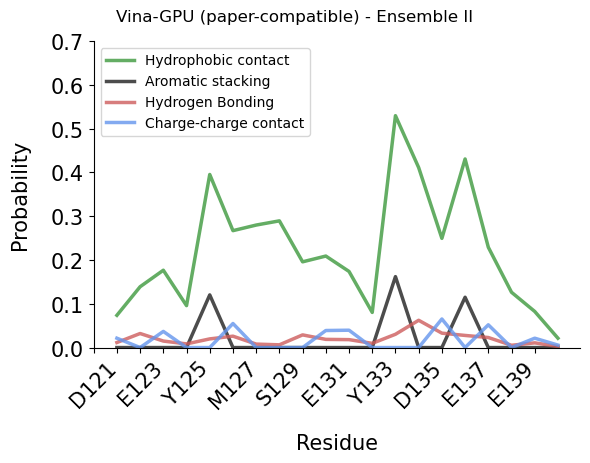

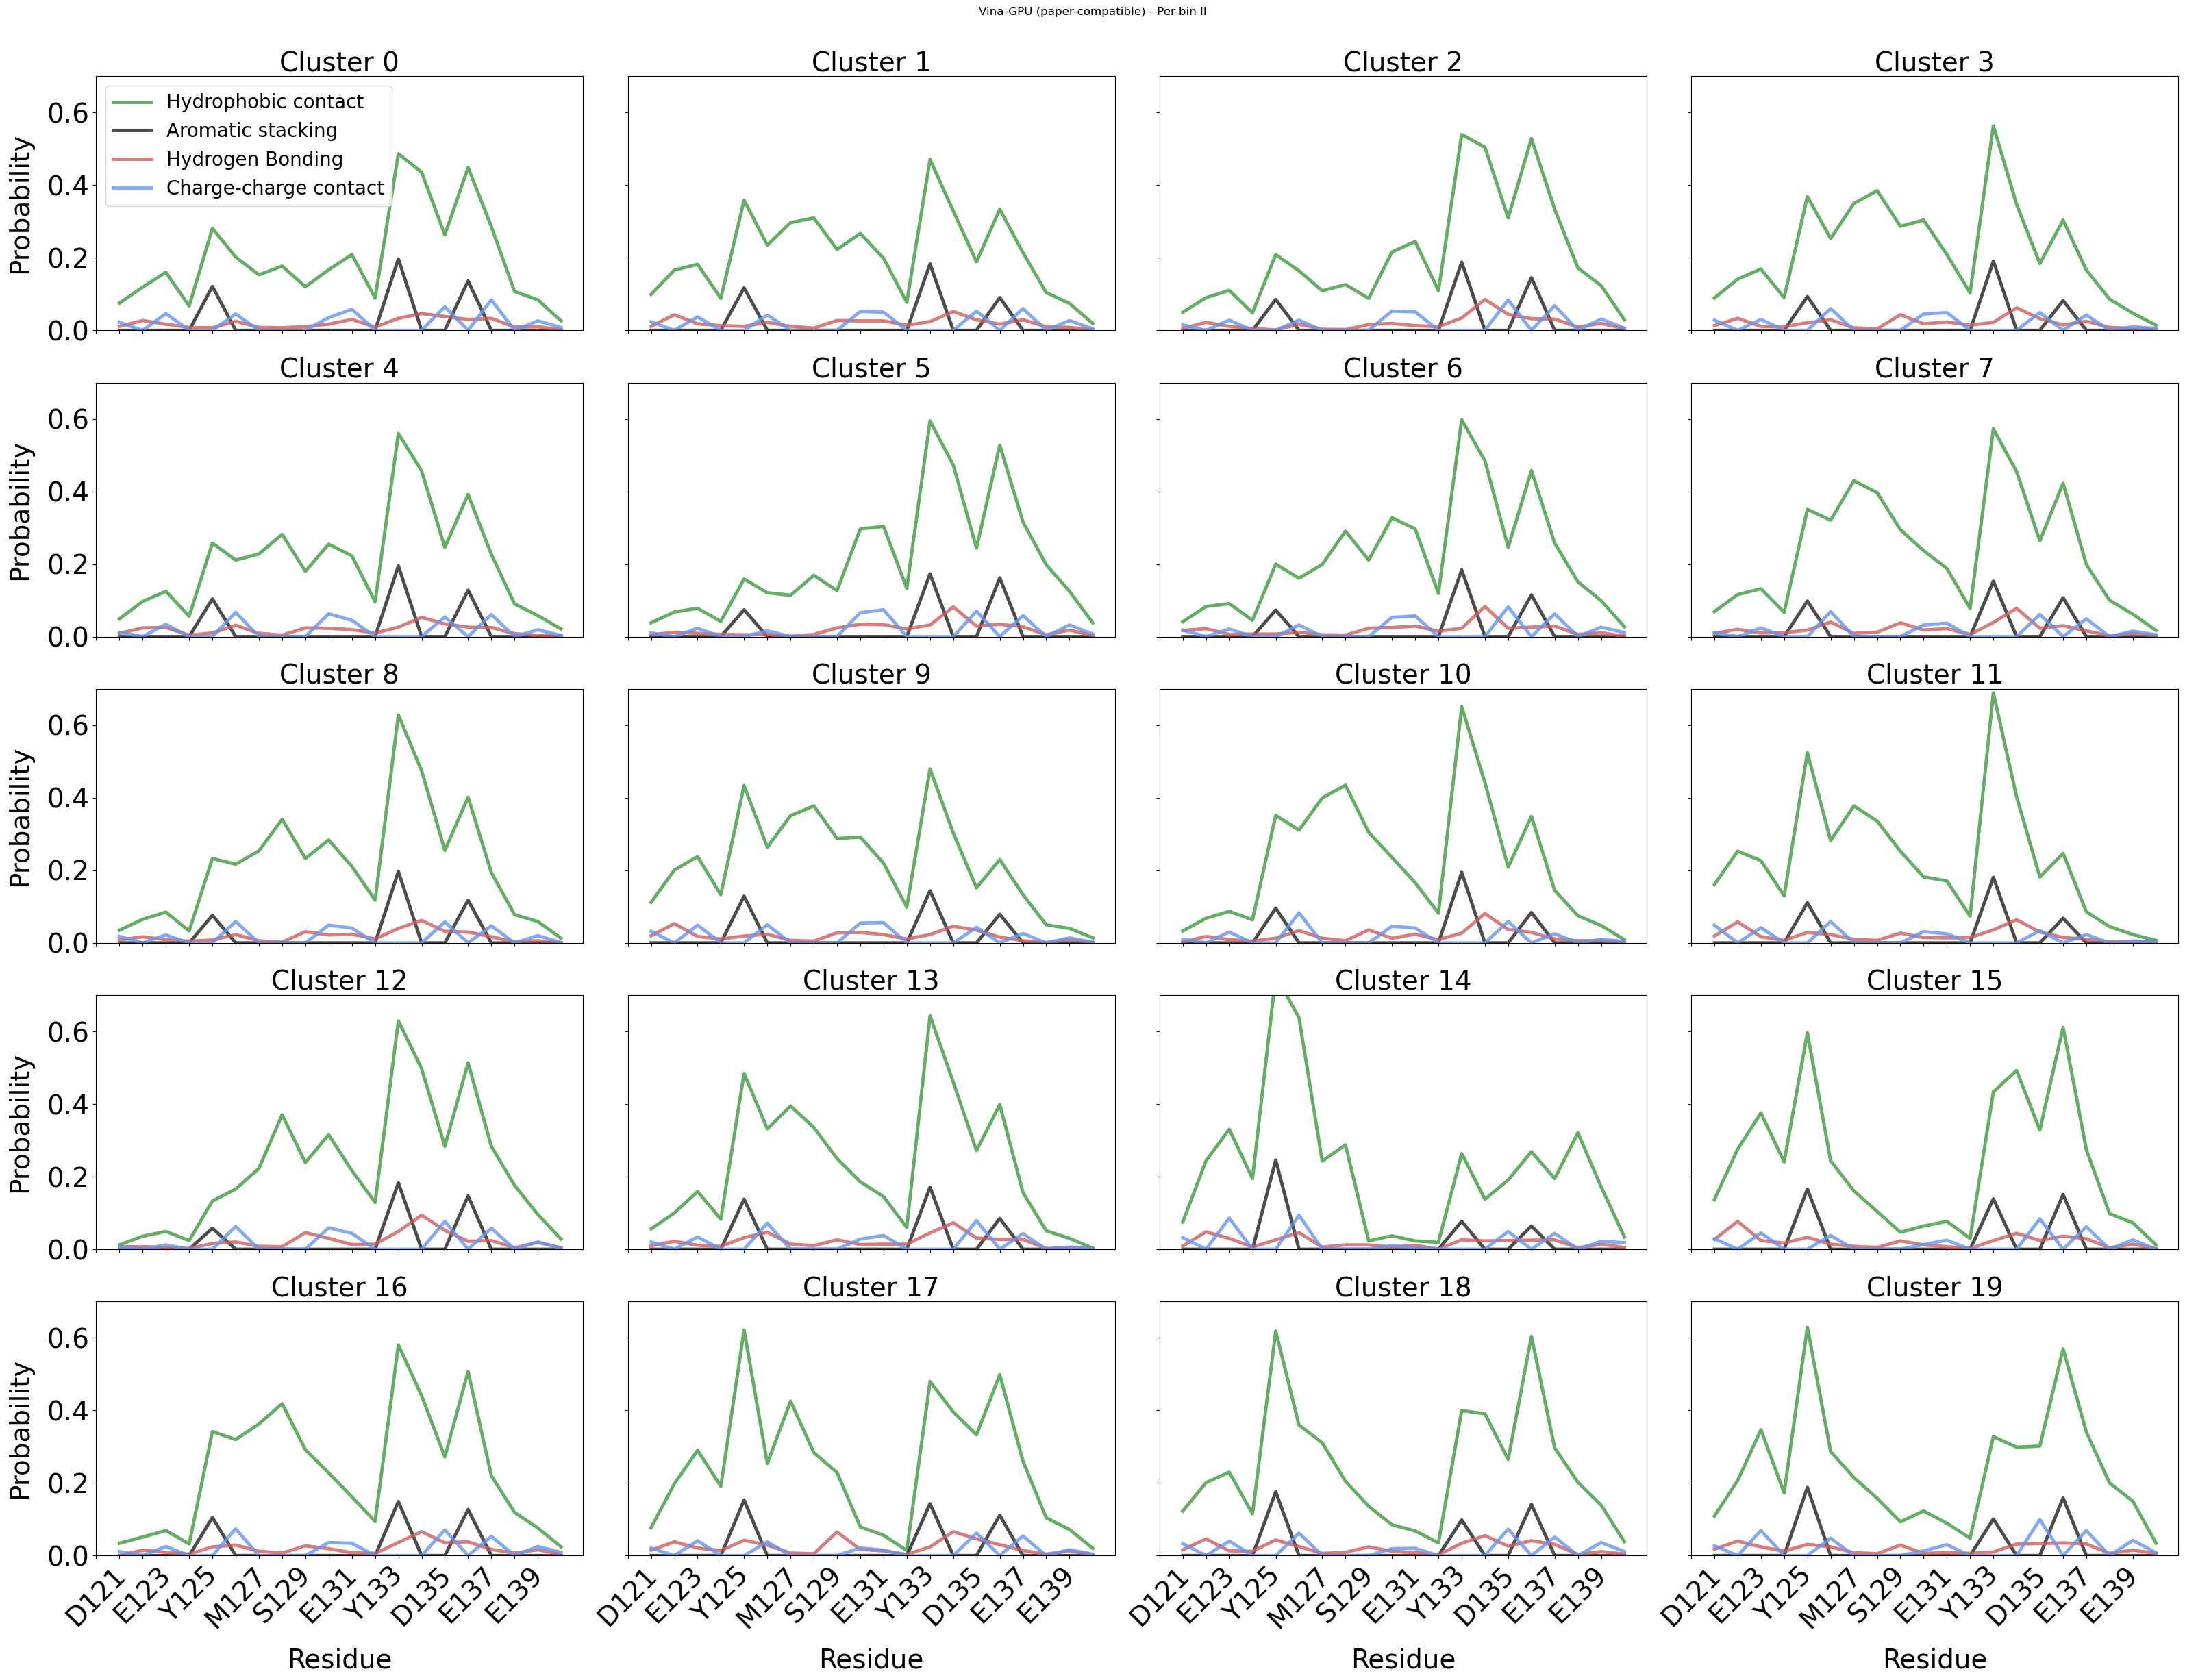

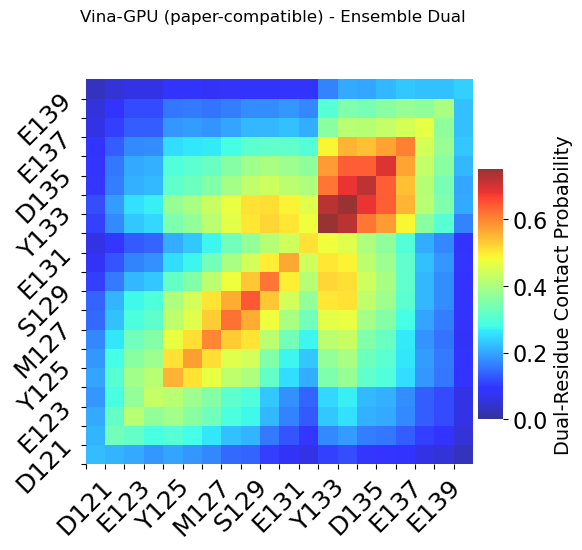

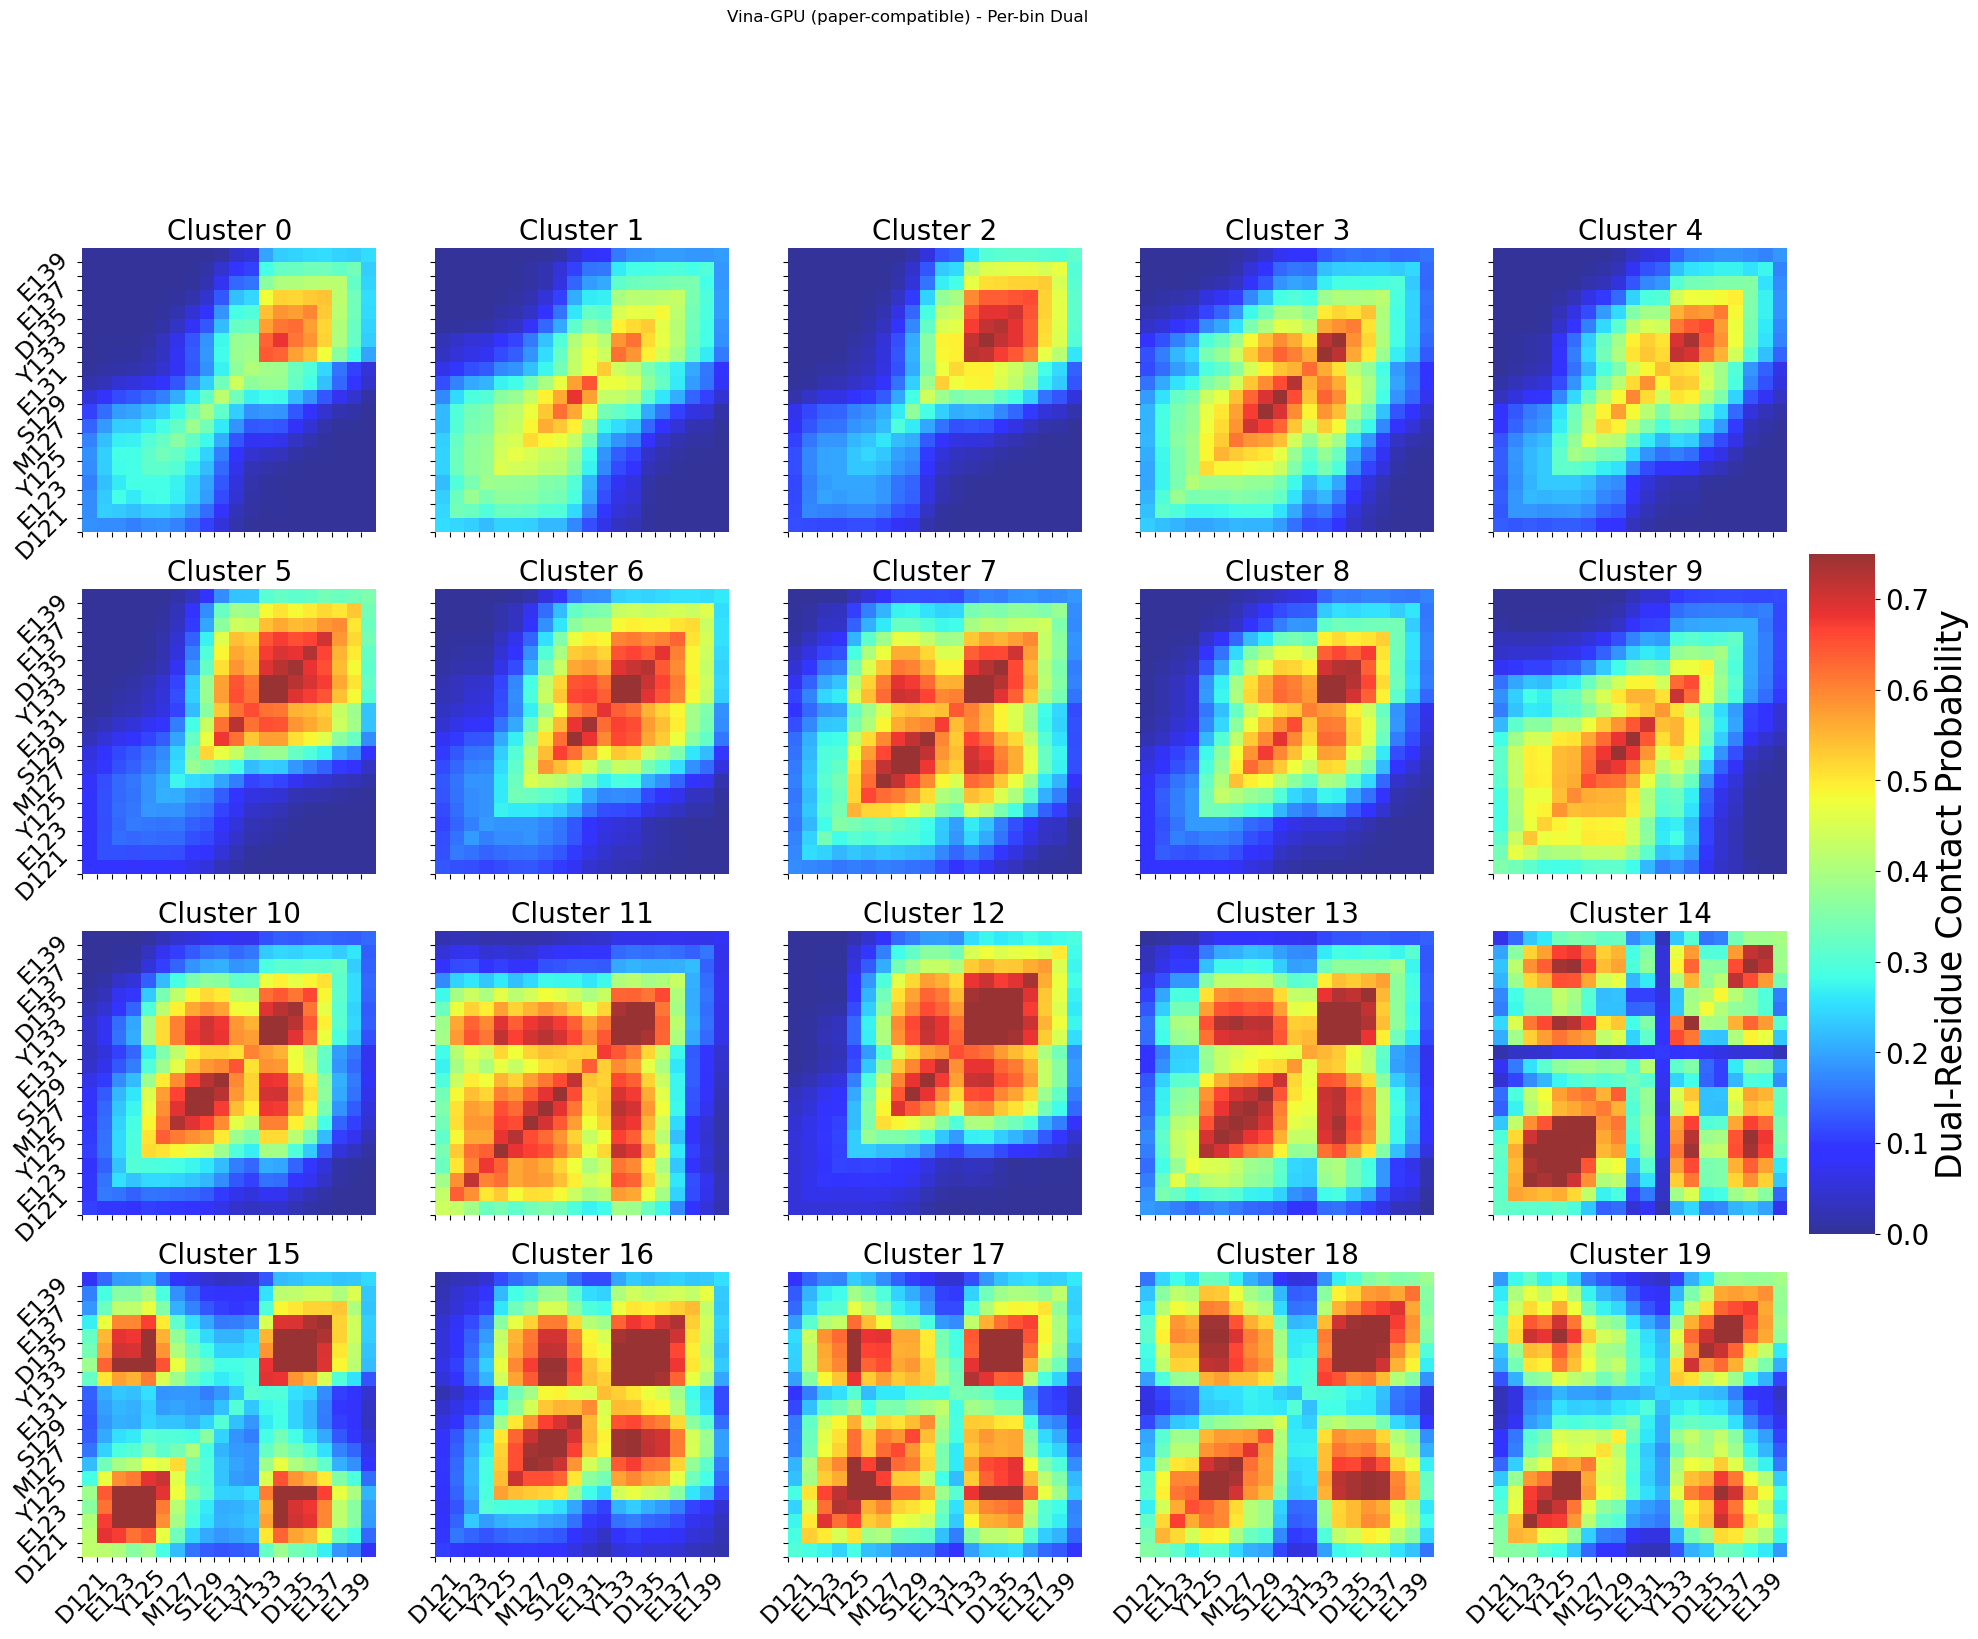

In [7]:
# ================================================================
# 7.  Interaction 
# ================================================================
if HAS_DOCKING_TOOLS:
    print("\n" + "=" * 70)
    print("STEP 5 - Interaction fingerprints (paper-style)")
    print("=" * 70)

    if vina_traj.n_frames < N_BINS:
        print(f"WARNING: only {vina_traj.n_frames} frames — "
              f"fewer than {N_BINS} bins. Reducing N_BINS.")
        n_bins = max(1, vina_traj.n_frames)
    else:
        n_bins = N_BINS

    bin_size  = vina_traj.n_frames // n_bins
    bin_trajs = [vina_traj[i*bin_size:(i+1)*bin_size] for i in range(n_bins)]
    bin_pop   = np.ones(n_bins) / n_bins

    contacts = {'hphob': [], 'aro': [], 'hbond': [], 'charge': [], 'dual': []}

    for i, traj in enumerate(bin_trajs):
        print(f"Bin {i+1:>2}: {traj.n_frames} frames", end=" | ")

        try:
            hp = trajectory_analysis.hphob_contacts(traj, LIGAND_RESID_PAPER)
            contacts['hphob'].append(hp)
            print(f"hphob={hp.mean(axis=0).sum():.3f}", end=" | ")
        except Exception as e:
            print(f"hphob ERR:{e}", end=" | ")
            contacts['hphob'].append(np.zeros((traj.n_frames, 20)))

        try:
            ar = trajectory_analysis.aro_contacts(
                traj, ligand_rings=[RING_BENZENE_PAPER])
            contacts['aro'].append(ar)
            print(f"aro={ar.mean(axis=0).sum():.3f}", end=" | ")
        except Exception as e:
            print(f"aro ERR:{e}", end=" | ")
            contacts['aro'].append(np.zeros((traj.n_frames, 20)))

        try:
            hb = trajectory_analysis.hbond(
                traj, LIGAND_RESID_PAPER,
                lig_hbond_donors=LIG_HBOND_DONORS_PAPER)
            contacts['hbond'].append(hb)
            print(f"hbond={hb.mean(axis=0).sum():.3f}", end=" | ")
        except Exception as e:
            print(f"hbond ERR:{e}", end=" | ")
            contacts['hbond'].append(np.zeros((traj.n_frames, 20)))

        try:
            ch = trajectory_analysis.charge_contacts(
                traj, Ligand_Pos_Charges=LIG_POS_CHARGES_PAPER)
            contacts['charge'].append(ch)
            print(f"charge={ch.mean(axis=0).sum():.3f}", end=" | ")
        except Exception as e:
            print(f"charge ERR:{e}", end=" | ")
            contacts['charge'].append(np.zeros((traj.n_frames, 20)))

        try:
            du = trajectory_analysis.dual_contact(
                traj, residue_idx=LIGAND_RESID_PAPER)
            contacts['dual'].append(du)
        except Exception:
            contacts['dual'].append(None)
        print()

    # Reshape for plotting
    contacts_plot = {}
    for key in ['hphob', 'aro', 'hbond', 'charge']:
        per_bin_means = [arr[:, :20].mean(axis=0) if arr is not None
                         else np.zeros(20) for arr in contacts[key]]
        contacts_plot[key] = np.array(per_bin_means)[:, np.newaxis, :]

    dual_v = [d for d in contacts['dual'] if d is not None]
    if dual_v:
        ds = dual_v[0].shape
        contacts_plot['dual'] = np.stack([
            d if d is not None else np.zeros(ds) for d in contacts['dual']])

    plotting.plot_ensemble_ii(contacts_plot, bin_pop[:, np.newaxis])
    plt.suptitle('Vina-GPU (paper-compatible) - Ensemble II', y=1.02)
    plt.savefig(OUT_DIR / 'ensemble_ii_vinagpu.png', dpi=150, bbox_inches='tight')
    plt.show()

    plotting.plot_clus_ii(contacts_plot)
    plt.suptitle('Vina-GPU (paper-compatible) - Per-bin II', y=1.02)
    plt.savefig(OUT_DIR / 'clus_ii_vinagpu.png', dpi=150, bbox_inches='tight')
    plt.show()

    if 'dual' in contacts_plot:
        plotting.plot_ensemble_dual(contacts_plot['dual'], bin_pop)
        plt.suptitle('Vina-GPU (paper-compatible) - Ensemble Dual', y=1.02)
        plt.savefig(OUT_DIR / 'ensemble_dual_vinagpu.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

        plotting.plot_clus_dual(contacts_plot['dual'])
        plt.suptitle('Vina-GPU (paper-compatible) - Per-bin Dual', y=1.02)
        plt.savefig(OUT_DIR / 'clus_dual_vinagpu.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

In [8]:
# ================================================================
# 8.  Save
# ================================================================
np.savez(OUT_DIR / 'vinagpu_results.npz',
         frame_ids=vina_frame_ids,
         scores=vina_scores,
         bound_fraction=bf_vina_ensemble[:20])

master = pd.DataFrame({'frame_id': vina_frame_ids, 'vinagpu_score': vina_scores})
master.to_csv(OUT_DIR / 'master_vinagpu_47.csv', index=False)

print(f"\nAll outputs in: {OUT_DIR}")
print("\nNotes:")
print("  - One winning pose per frame, chosen as the lowest-affinity mode-1")
print("    across all 20 search boxes (res01..res20).")
print("  - Scores are Vina kcal/mol — directly comparable to old Vina script;")
print("    NOT directly comparable to AutoDock-GPU scoring.")
print("  - box_winner_per_frame.csv lets you see which box won each frame —")
print("    useful for spotting whether one region of the surface dominates.")


All outputs in: /home/zhihanz/data/VinaGPU/analysis_paper_compatible

Notes:
  - One winning pose per frame, chosen as the lowest-affinity mode-1
    across all 20 search boxes (res01..res20).
  - Scores are Vina kcal/mol — directly comparable to old Vina script;
    NOT directly comparable to AutoDock-GPU scoring.
  - box_winner_per_frame.csv lets you see which box won each frame —
    useful for spotting whether one region of the surface dominates.
